## Heart Disease Dataset - Machine Learning

#### Objective

The objective of this notebook is to build and compare multiple machine learning models to predict the presence of heart disease in patients based on clinical features.

The analysis aims to:
- Identify key factors that contribute to heart disease
- Evaluate the performance of different classification models
- Determine the most suitable model for accurate and reliable prediction

This can help in early detection and risk assessment in healthcare settings.

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

In [67]:
df = pd.read_csv(r"clean_heart_data.csv")
X=df.drop(["heart_disease","patient_id"],axis=1)
y=df['heart_disease']

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [69]:
X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,y,
    test_size=0.2,
    random_state=42
)

In [70]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [71]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.54      0.39      0.45        80
           1       0.51      0.66      0.58        77

    accuracy                           0.52       157
   macro avg       0.53      0.52      0.51       157
weighted avg       0.53      0.52      0.51       157



In [72]:
coeff = pd.Series(model.coef_[0], index=X.columns)
coeff.sort_values(ascending=False)

age                        0.116781
exercise_induced_angina    0.077127
gender                     0.040490
chest_pain_type            0.014787
cholesterol_mg/dl         -0.038346
max_heart_rate            -0.057100
st_depression             -0.082740
resting_bp_mmhg           -0.103451
dtype: float64

* The Accuracy is very low (52%). Precision 51%: out of 100 patients identified with heart disease, only 51 are truly diseased. Recall 66%: out of 100 true patients, the model determined only 58 patients.
* All the coefficient values are near 0. No particular parameter is vital alone in determining heart disease.

In [73]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=99)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("accuracy:",accuracy_score(y_test,y_pred))

accuracy: 0.5414012738853503


In [74]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.45      0.50        80
           1       0.53      0.64      0.58        77

    accuracy                           0.54       157
   macro avg       0.54      0.54      0.54       157
weighted avg       0.55      0.54      0.54       157



The Accuracy is very low (54%). Precision 53%: out of 100 patients identified with heart disease, only 53 are truly diseased. Recall 64%: out of 100 true patients, the model identified only 64.

In [84]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("accuracy:",accuracy_score(y_test,y_pred))

accuracy: 0.5031847133757962


In [85]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.52      0.35      0.42        80
           1       0.50      0.66      0.57        77

    accuracy                           0.50       157
   macro avg       0.51      0.51      0.49       157
weighted avg       0.51      0.50      0.49       157



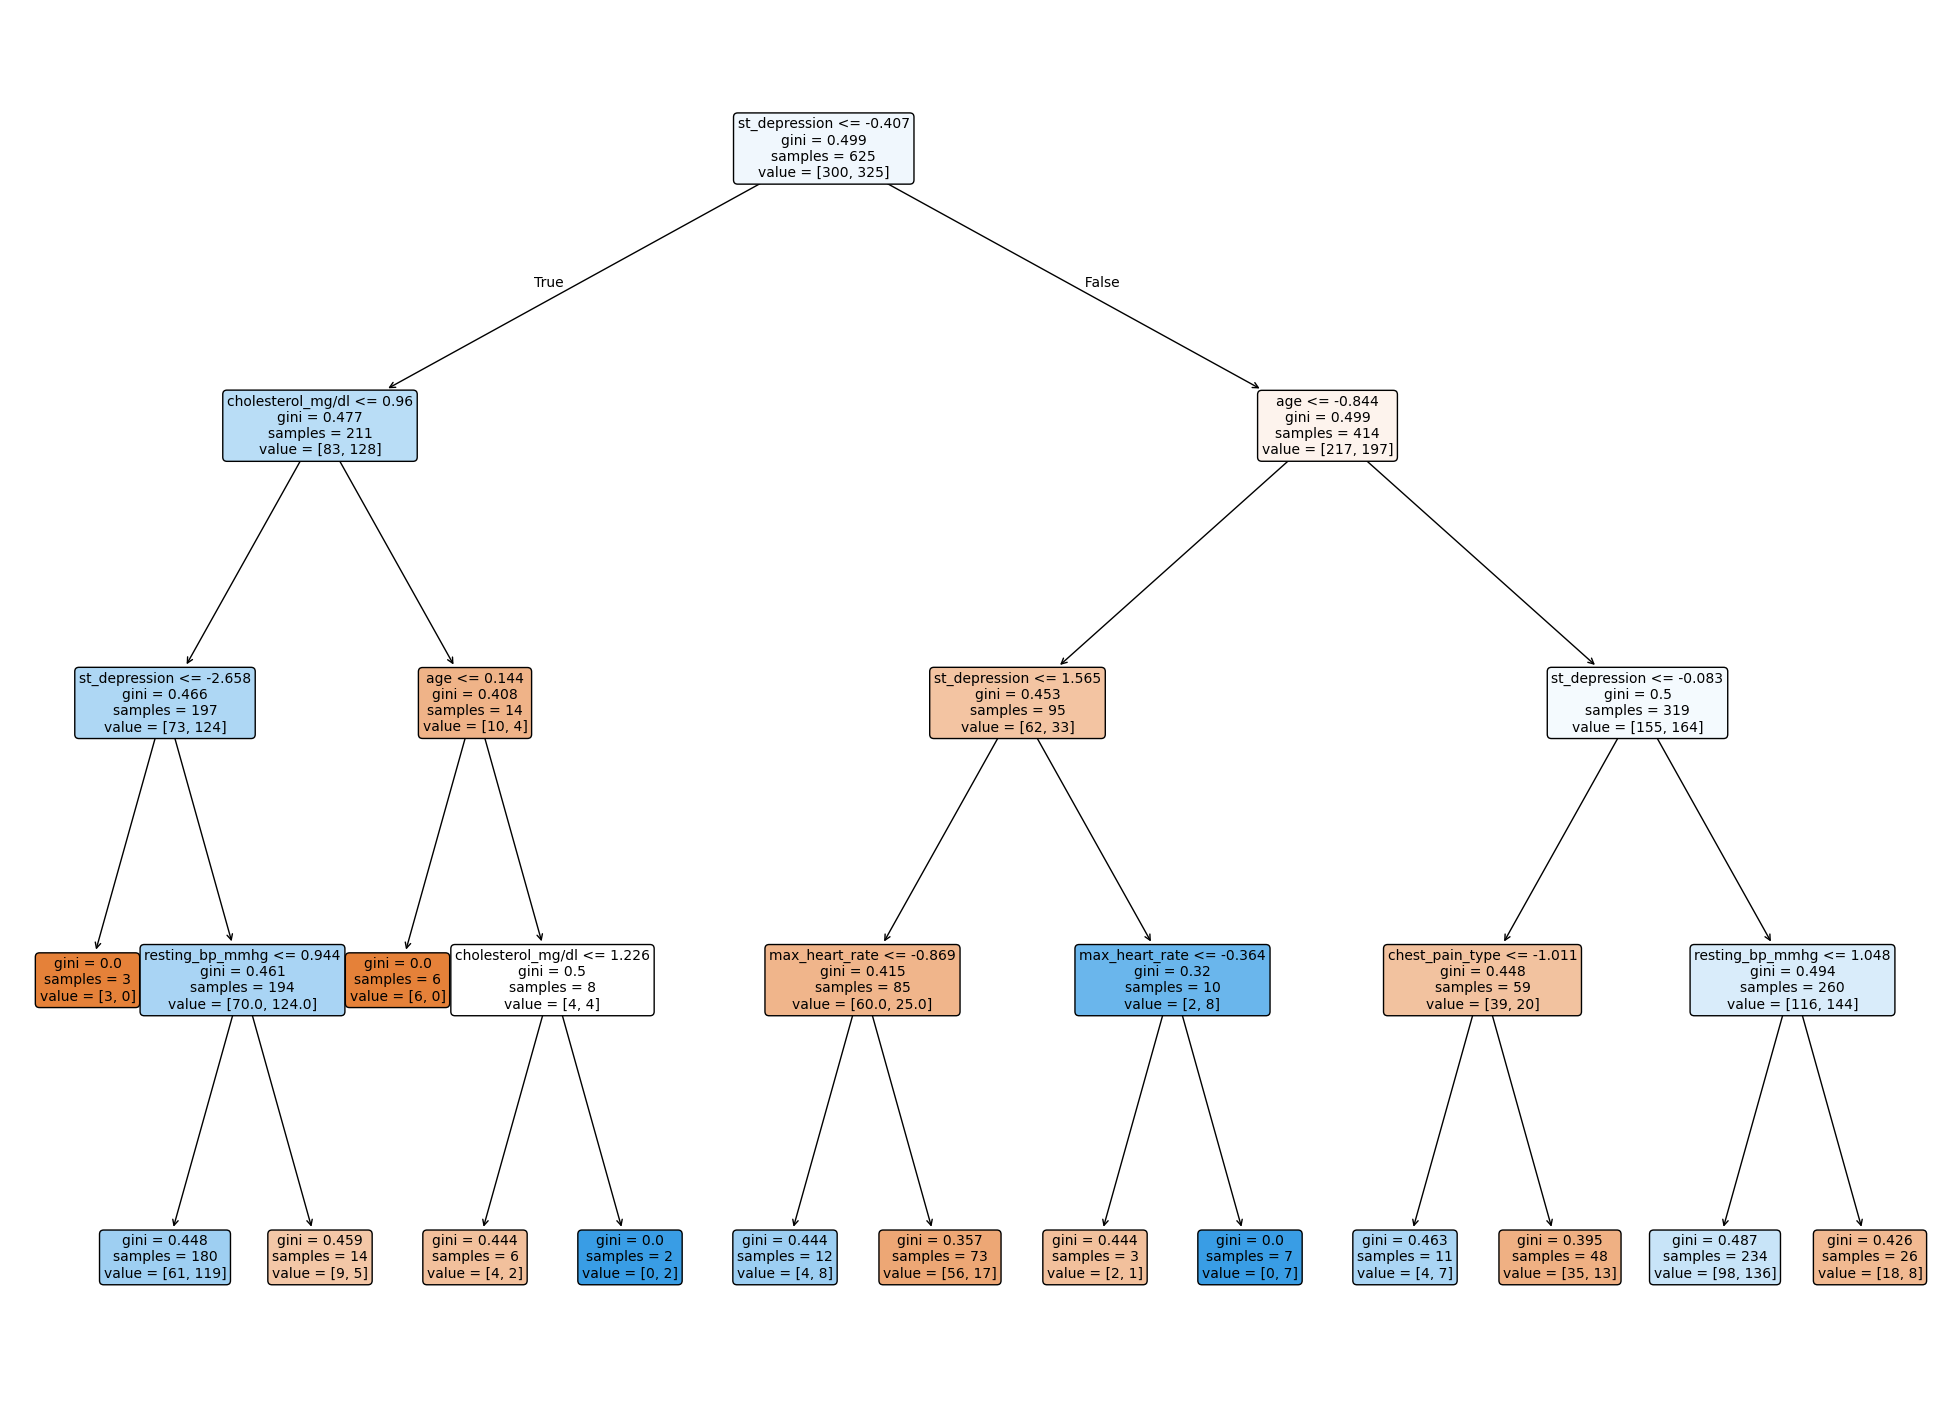

In [86]:
plt.figure(figsize=(25,18))
plot_tree(model,feature_names=X.columns,filled=True)
plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

## 🌳 Decision Tree Insights

The decision tree reveals that ST depression (oldpeak) is the most important factor in predicting heart disease, as it is used at the root node for the first split.

Age also plays a significant role, further refining the prediction after the initial split.

Overall, the model suggests that clinical indicators related to heart stress and patient age are key drivers in determining heart disease risk.

## Conclusion

We trained 3 models:
1. Logistic Regression
2. KNN
3. Decision Tree

Out of the three models trained, the "KNN" model provides somewhat better result than other two models. This implies that, though no model is "usable" in the determination of heart disease for this particular dataset, the "KNN" is the most successful model.